
# Integration Module — Applying Part 1 effluent output to Part 2 Plant Growth Module_Checkpoint 2

This notebook integrates:
- upstream nitrification output from `simulate_part1_checkpoint2.py`
- fitted growth parameters from the growth-module notebook
- fitted uptake parameters from the uptake-module notebook

## What is included
1. **Usable-start vs quasi-steady-start comparison** using **Dynamic-μ only**  
   This section is meant to compare the effect of the two start definitions on the integrated simulation.

2. **All-method comparison** under the same upstream-driven nitrogen forcing  
   This section compares:
   - Dynamic-μ
   - RMND-μ
   - SMND-μ
   - Liebig minimum Monod
   - Multiplicative Monod

## Important modeling note
- Downstream nitrogen input is treated as a **forcing signal**:
  \[
  N(t) = NO_3(t) + NH_4(t)
  \]
- P and K are kept constant (P and K concentrations non-limiting).
- The **usable-start vs quasi-steady-start** section uses **Dynamic-μ only**.
- The **method-comparison** section uses **all growth methods**.


In [3]:

import json
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")


In [4]:
# CONFIG

UPSTREAM_FILE = "simulate_part1_checkpoint2.py"
EXCEL_PATH = "NPK.CrossT.All.xlsx"

# Exported parameter files from the two module notebooks
GROWTH_PARAMS_JSON = "fitted_growth_params_all.json"
UPTAKE_PARAMS_JSON = "fitted_uptake_params_global.json"

# Choose the growth model to apply in the integrated run
MODEL_NAME = "dynamic"   # dynamic, rmnd, smnd, liebig, multiplicative

# If the selected model keeps P and K non-limiting (dynamic μ case)
DYNAMIC_PK_SOURCE = "MSS"  # MSS or MAX

# Crop cycle length (days). If None, infer from the dataset as max Growth Day.
CROP_CYCLE_DAYS = None

# -------- Usable-start rule (earlier start, around ~5 d) --------
# It is the earliest post-startup time at which the reactor output is considered usable
# for downstream illustration because basic aerobic operability is satisfied.
USE_MIN_DAY = 5.0
USE_DO_MIN = 7.5
USE_HOLD_DAYS = 3.0

# -------- Quasi-steady-state rule (later start, around ~35–40 d) --------
# Based on forward-window stability of total downstream-used N = NH4 + NO3.
QS_MIN_DAY = 5.0
QS_HOLD_DAYS = 10.0
QS_ABS_TOL = 0.05   # mg N/L

In [5]:
def load_upstream_module(pyfile):
    spec = importlib.util.spec_from_file_location("upstream_mod", pyfile)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

up_mod = load_upstream_module(UPSTREAM_FILE)

t_up = np.asarray(up_mod.t, dtype=float)
sol_up = np.asarray(up_mod.sol, dtype=float)

NH4 = sol_up[:, 0]
NO2 = sol_up[:, 1]
NO3 = sol_up[:, 2]
DO  = sol_up[:, 3]
XAOB = sol_up[:, 4]
XNOB = sol_up[:, 5]

N_total = NH4 + NO3

print("Upstream loaded:", sol_up.shape)
print("Time range:", float(t_up.min()), "to", float(t_up.max()))

Upstream loaded: (50000, 6)
Time range: 0.0 to 100.0


In [6]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

growth_params = load_json(GROWTH_PARAMS_JSON)
uptake_params = load_json(UPTAKE_PARAMS_JSON)

print("Growth models:", list(growth_params.keys()))
print("Uptake keys:", list(uptake_params.keys()))


Growth models: ['dynamic', 'rmnd', 'smnd', 'liebig', 'multiplicative']
Uptake keys: ['global']


In [7]:
# Load dataset again for treatment summary / scenario constants

fit_df = pd.read_excel(EXCEL_PATH, sheet_name="ModSummary", header=1)

rename_map = {}
for c in fit_df.columns:
    cs = str(c).strip()
    if cs == "DM (g)":
        rename_map[c] = "DM"
    elif cs == "Treatment mg/L N":
        rename_map[c] = "N_target"
    elif cs == "Treatment mg/L P":
        rename_map[c] = "P_target"
    elif cs == "Treatment mg/L K":
        rename_map[c] = "K_target"
fit_df = fit_df.rename(columns=rename_map)

def normalize_category(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s in {"N", "N-LIMITED", "N LIMITED"}:
        return "N"
    if s in {"P", "P-LIMITED", "P LIMITED"}:
        return "P"
    if s in {"K", "K-LIMITED", "K LIMITED"}:
        return "K"
    if s in {"MSS", "SUFFICIENT", "NUTRIENT SUFFICIENT", "CONTROL"}:
        return "MSS"
    return s

if "Category" in fit_df.columns:
    fit_df["Category"] = fit_df["Category"].apply(normalize_category)
elif "Limiting Nutrient" in fit_df.columns:
    fit_df["Category"] = fit_df["Limiting Nutrient"].apply(normalize_category)

required_cols = ["Treatment", "Growth Day", "DM", "Category"]
missing = [c for c in required_cols if c not in fit_df.columns]
if missing:
    raise ValueError(f"Missing required columns in ModSummary: {missing}")

# Try to get N/P/K from direct columns first; otherwise lifetime average columns
if "N" not in fit_df.columns:
    if "Lifetime Avg [N]" in fit_df.columns:
        fit_df["N"] = pd.to_numeric(fit_df["Lifetime Avg [N]"], errors="coerce")
    elif "Harvest [N] (mg/L)" in fit_df.columns:
        fit_df["N"] = pd.to_numeric(fit_df["Harvest [N] (mg/L)"], errors="coerce")

if "P" not in fit_df.columns:
    if "Lifetime Avg [P]" in fit_df.columns:
        fit_df["P"] = pd.to_numeric(fit_df["Lifetime Avg [P]"], errors="coerce")
    elif "Harvest [P] (mg/L)" in fit_df.columns:
        fit_df["P"] = pd.to_numeric(fit_df["Harvest [P] (mg/L)"], errors="coerce")

if "K" not in fit_df.columns:
    if "Lifetime Avg [K]" in fit_df.columns:
        fit_df["K"] = pd.to_numeric(fit_df["Lifetime Avg [K]"], errors="coerce")
    elif "Harvest [K] (mg/L)" in fit_df.columns:
        fit_df["K"] = pd.to_numeric(fit_df["Harvest [K] (mg/L)"], errors="coerce")

required_npk = ["N", "P", "K"]
missing_npk = [c for c in required_npk if c not in fit_df.columns]
if missing_npk:
    raise ValueError(f"Missing N/P/K columns in ModSummary: {missing_npk}")

fit_df = fit_df.dropna(subset=["Treatment", "Growth Day", "DM", "N", "P", "K", "Category"]).copy()
fit_df["Growth Day"] = pd.to_numeric(fit_df["Growth Day"], errors="coerce")
fit_df["DM"] = pd.to_numeric(fit_df["DM"], errors="coerce")
fit_df["N"] = pd.to_numeric(fit_df["N"], errors="coerce")
fit_df["P"] = pd.to_numeric(fit_df["P"], errors="coerce")
fit_df["K"] = pd.to_numeric(fit_df["K"], errors="coerce")
fit_df = fit_df.dropna(subset=["Growth Day", "DM", "N", "P", "K"]).copy()

if CROP_CYCLE_DAYS is None:
    CROP_CYCLE_DAYS = float(fit_df["Growth Day"].max())
    print(f"Inferred CROP_CYCLE_DAYS = {CROP_CYCLE_DAYS}")

fit_df.head()


Inferred CROP_CYCLE_DAYS = 32.0


C:\Users\ruixi\anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Web Extension extension is not supported and will be removed
  for idx, row in parser.parse():


,ID#,Limiting Nutrient,Treatment %,Round,Treatment,N_target,P_target,K_target,Growth Day,Pre/Post,...,Lifetime Average [Mg],Harvest [Mg] (mg/L),Lifetime Average [S],Harvest [S] (mg/L),Lifetime Average [Fe],Harvest [Fe] (mg/L),Category,N,P,K
0,1,MSS,1.0,R22,R22,132.0,31.0,210.0,0,-,...,18.657920,NaN,23.864060,NaN,0.717571,NaN,MSS,115.772222,21.627333,138.079303
7,8,MSS,1.0,R22,R22,132.0,31.0,210.0,14,Pre,...,19.153359,19.153359,24.660261,24.660261,0.764942,0.764942,MSS,110.744444,20.532344,138.326229
10,11,MSS,1.0,R22,R22,132.0,31.0,210.0,18,Pre,...,19.101866,18.964552,24.914391,25.592071,0.759382,0.744555,MSS,102.003535,18.410037,129.579032
12,13,MSS,1.0,R22,R22,132.0,31.0,210.0,21,Pre,...,19.459436,21.426068,25.350871,27.751510,0.775276,0.862690,MSS,98.637991,17.858158,126.873861
16,17,MSS,1.0,R22,R22,132.0,31.0,210.0,25,Pre,...,20.042229,21.936306,26.248994,29.167895,0.769083,0.748955,MSS,94.198660,16.323061,126.085750


In [8]:

# Start-time detection

def first_usable_start_time(t, do, min_day=5.0, do_min=7.5, hold_days=3.0):
    """
    Early usable start time:
    earliest time after min_day such that DO stays above do_min for a short hold window.
    This gives an 'early operable / usable' start, not a quasi-steady-state start.
    """
    t = np.asarray(t, dtype=float)
    do = np.asarray(do, dtype=float)

    for i in range(len(t)):
        if t[i] < min_day:
            continue
        t_end = t[i] + hold_days
        j = np.searchsorted(t, t_end, side="right") - 1
        if j <= i:
            continue
        if np.all(do[i:j+1] >= do_min):
            return float(t[i]), {
                "do_min": float(do_min),
                "hold_days": float(hold_days),
                "min_day": float(min_day)
            }
    return float(min_day), None

def first_quasi_steady_time_totalN(t, n_total, min_day=5.0, hold_days=10.0, abs_tol=0.05):
    """
    Strict quasi-steady-state start based on forward-window stability of total N.
    Find earliest t >= min_day such that max deviation over [t, t+hold_days] is <= abs_tol.
    """
    t = np.asarray(t, dtype=float)
    n_total = np.asarray(n_total, dtype=float)

    for i in range(len(t)):
        if t[i] < min_day:
            continue
        t_end = t[i] + hold_days
        j = np.searchsorted(t, t_end, side="right") - 1
        if j <= i:
            continue
        ref = n_total[i]
        y_win = n_total[i:j+1]
        max_dev = float(np.max(np.abs(y_win - ref)))
        if max_dev <= abs_tol:
            return float(t[i]), {
                "hold_days": float(hold_days),
                "abs_tol": float(abs_tol),
                "max_dev": max_dev
            }
    return float(t[-1] - hold_days), None

usable_start, usable_info = first_usable_start_time(
    t_up, DO,
    min_day=USE_MIN_DAY,
    do_min=USE_DO_MIN,
    hold_days=USE_HOLD_DAYS
)

qs_start, qs_info = first_quasi_steady_time_totalN(
    t_up, N_total,
    min_day=QS_MIN_DAY,
    hold_days=QS_HOLD_DAYS,
    abs_tol=QS_ABS_TOL
)

print("Usable start time =", usable_start)
print("Usable-start info =", usable_info)
print("Quasi-steady start time =", qs_start)
print("Quasi-steady info =", qs_info)


Usable start time = 5.00010000200004
Usable-start info = {'do_min': 7.5, 'hold_days': 3.0, 'min_day': 5.0}
Quasi-steady start time = 33.98067961359227
Quasi-steady info = {'hold_days': 10.0, 'abs_tol': 0.05, 'max_dev': 0.04997500726838844}


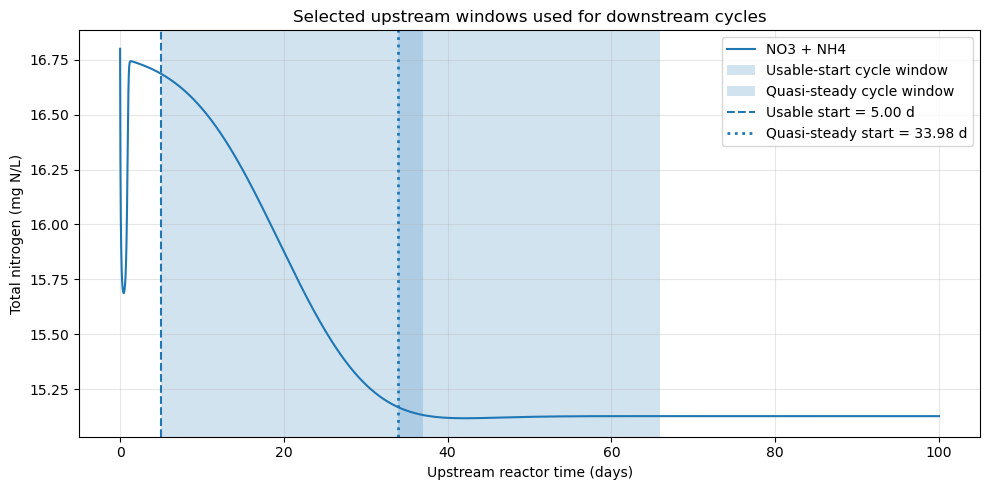

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(t_up, N_total, label="NO3 + NH4")
plt.axvspan(usable_start, usable_start + CROP_CYCLE_DAYS, alpha=0.20, label="Usable-start cycle window")
plt.axvspan(qs_start, qs_start + CROP_CYCLE_DAYS, alpha=0.20, label="Quasi-steady cycle window")
plt.axvline(usable_start, linestyle="--", label=f"Usable start = {usable_start:.2f} d")
plt.axvline(qs_start, linestyle=":", linewidth=2, label=f"Quasi-steady start = {qs_start:.2f} d")
plt.xlabel("Upstream reactor time (days)")
plt.ylabel("Total nitrogen (mg N/L)")
plt.title("Selected upstream windows used for downstream cycles")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Treatment summary and matching

treat_summary = (
    fit_df.groupby("Treatment", as_index=False)
    .agg(
        N_mean=("N", "mean"),
        P_mean=("P", "mean"),
        K_mean=("K", "mean"),
        Category=("Category", "first"),
        B0=("DM", "first")
    )
)

def cycle_mean_total_n(t, n_total, start, duration):
    mask = (t >= start) & (t <= start + duration)
    if not np.any(mask):
        return np.nan
    return float(np.mean(n_total[mask]))

def match_treatment_by_cycle_mean_N(cycle_mean_n, treat_summary_df):
    idx = int(np.argmin(np.abs(treat_summary_df["N_mean"].values - cycle_mean_n)))
    return treat_summary_df.iloc[idx]

usable_meanN = cycle_mean_total_n(t_up, N_total, usable_start, CROP_CYCLE_DAYS)
qs_meanN = cycle_mean_total_n(t_up, N_total, qs_start, CROP_CYCLE_DAYS)

usable_match = match_treatment_by_cycle_mean_N(usable_meanN, treat_summary)
qs_match = match_treatment_by_cycle_mean_N(qs_meanN, treat_summary)

print("Usable-start cycle mean N:", usable_meanN)
display(usable_match.to_frame().T)
print("Quasi-steady cycle mean N:", qs_meanN)
display(qs_match.to_frame().T)

Usable-start cycle mean N: 15.845918369350514


,Treatment,N_mean,P_mean,K_mean,Category,B0
0,R09N,17.437497,51.841473,151.829072,N,0.001878


Quasi-steady cycle mean N: 15.126201032575047


,Treatment,N_mean,P_mean,K_mean,Category,B0
0,R09N,17.437497,51.841473,151.829072,N,0.001878


In [11]:
# Growth and uptake helpers

def frac_monod(s, ks):
    s = max(float(s), 1e-12)
    ks = max(float(ks), 1e-12)
    return s / (ks + s)

def michaelis_menten(n, umax, km):
    n = np.asarray(n, dtype=float)
    n = np.clip(n, 0.0, None)
    return umax * n / (km + n + 1e-12)

def get_nonlimiting_pk(df, source="MSS"):
    source = str(source).strip().upper()
    if source == "MSS":
        mss = df[df["Category"] == "MSS"]
        if len(mss) > 0:
            return float(mss["P"].mean()), float(mss["K"].mean())
    return float(df["P"].max()), float(df["K"].max())

PK_NONLIMITING = get_nonlimiting_pk(fit_df, source=DYNAMIC_PK_SOURCE)

def calc_mu(model_name, t_crop, n_t, p_const, k_const, category, params):
    if model_name == "dynamic":
        return max(
            params["mu_max"] * frac_monod(n_t, params["Ks"])
            + params["m"] * max(0.0, t_crop - params["delay"]),
            0.0
        )
    elif model_name == "rmnd":
        mu_key = f"mu_max_{category}"
        m_key = f"m_{category}"
        d_key = f"delay_{category}"
        mu = params[mu_key]
        mu *= frac_monod(n_t, params["KsN"])
        mu *= frac_monod(p_const, params["KsP"])
        mu *= frac_monod(k_const, params["KsK"])
        mu += params[m_key] * max(0.0, t_crop - params[d_key])
        return max(mu, 0.0)
    elif model_name == "smnd":
        mu = params["mu_max"]
        mu *= frac_monod(n_t, params["KsN"])
        mu *= frac_monod(p_const, params["KsP"])
        mu *= frac_monod(k_const, params["KsK"])
        mu += params["m"] * max(0.0, t_crop - params["delay"])
        return max(mu, 0.0)
    elif model_name == "liebig":
        fmin = min(
            frac_monod(n_t, params["KsN"]),
            frac_monod(p_const, params["KsP"]),
            frac_monod(k_const, params["KsK"]),
        )
        return max(params["mu_max"] * fmin, 0.0)
    elif model_name == "multiplicative":
        mu = params["mu_max"]
        mu *= frac_monod(n_t, params["KsN"])
        mu *= frac_monod(p_const, params["KsP"])
        mu *= frac_monod(k_const, params["KsK"])
        return max(mu, 0.0)
    else:
        raise ValueError(f"Unknown MODEL_NAME: {model_name}")

def get_growth_param_dict(model_name, growth_params_json):
    if model_name not in growth_params_json:
        raise KeyError(f"{model_name} not found in growth parameter JSON.")
    params = dict(growth_params_json[model_name])
    params.pop("success", None)
    params.pop("objective", None)
    return params

def get_uptake_param_dict(uptake_params_json):
    if "global" in uptake_params_json:
        params = dict(uptake_params_json["global"])
    else:
        params = dict(uptake_params_json)
    params.pop("metrics", None)
    params.pop("x_col", None)
    params.pop("y_col", None)
    params.pop("sheet_name", None)
    params.pop("screen_col", None)
    return params

In [12]:
# Uptake model helpers
def michaelis_menten(n, umax, km):
    n = np.asarray(n, dtype=float)
    n = np.clip(n, 0.0, None)
    return umax * n / (km + n + 1e-12)

def simulate_uptake(forcing, uptake_params):
    n_series = np.asarray(forcing["N"], dtype=float)
    u = michaelis_menten(n_series, uptake_params["Umax"], uptake_params["Km"])
    return {
        "t_crop": np.asarray(forcing["t"], dtype=float),
        "uptake": u
    }

uptake_global = uptake_params["global"]

## A. Usable-start vs quasi-steady-start comparison 
Growth module using Dynamic-μ simulation.

In [14]:
# Integrated cycle simulation

def simulate_cycle(model_name, cycle_start, cycle_days, matched_row):
    mask = (t_up >= cycle_start) & (t_up <= cycle_start + cycle_days)
    if not np.any(mask):
        raise ValueError("Selected cycle window contains no upstream points.")

    t_window = t_up[mask]
    n_window = N_total[mask]

    # Re-index to crop age
    t_crop = t_window - t_window[0]

    category = str(matched_row["Category"])
    B0 = float(matched_row["B0"])
    p_const = float(matched_row["P_mean"])
    k_const = float(matched_row["K_mean"])

    if model_name == "dynamic":
        p_const, k_const = PK_NONLIMITING

    gpars = get_growth_param_dict(model_name, growth_params)
    upars = get_uptake_param_dict(uptake_params)

    mu_series = np.array([
        calc_mu(model_name, tc, n_t, p_const, k_const, category, gpars)
        for tc, n_t in zip(t_crop, n_window)
    ], dtype=float)

    U_series = michaelis_menten(n_window, upars["Umax"], upars["Km"])

    DM = np.zeros_like(t_crop, dtype=float)
    dDMdt = np.zeros_like(t_crop, dtype=float)
    DM[0] = B0
    dDMdt[0] = mu_series[0] * DM[0]

    for i in range(1, len(t_crop)):
        dt = float(t_crop[i] - t_crop[i - 1])
        DM[i] = DM[i - 1] * np.exp(mu_series[i - 1] * dt)
        dDMdt[i] = mu_series[i] * DM[i]

    return {
        "start": float(cycle_start),
        "duration": float(cycle_days),
        "matched_treatment": str(matched_row["Treatment"]),
        "category": category,
        "P_const": p_const,
        "K_const": k_const,
        "B0": B0,
        "t_up_window": t_window,
        "t_crop": t_crop,
        "N_input": n_window,
        "mu": mu_series,
        "U": U_series,
        "DM": DM,
        "dDMdt": dDMdt,
    }
MODEL_NAME
sim_usable = simulate_cycle(MODEL_NAME, usable_start, CROP_CYCLE_DAYS, usable_match)
sim_qs = simulate_cycle(MODEL_NAME, qs_start, CROP_CYCLE_DAYS, qs_match)

print("Usable-start cycle matched treatment:", sim_usable["matched_treatment"], "| category:", sim_usable["category"])
print("Quasi-steady cycle matched treatment:", sim_qs["matched_treatment"], "| category:", sim_qs["category"])


Usable-start cycle matched treatment: R09N | category: N
Quasi-steady cycle matched treatment: R09N | category: N


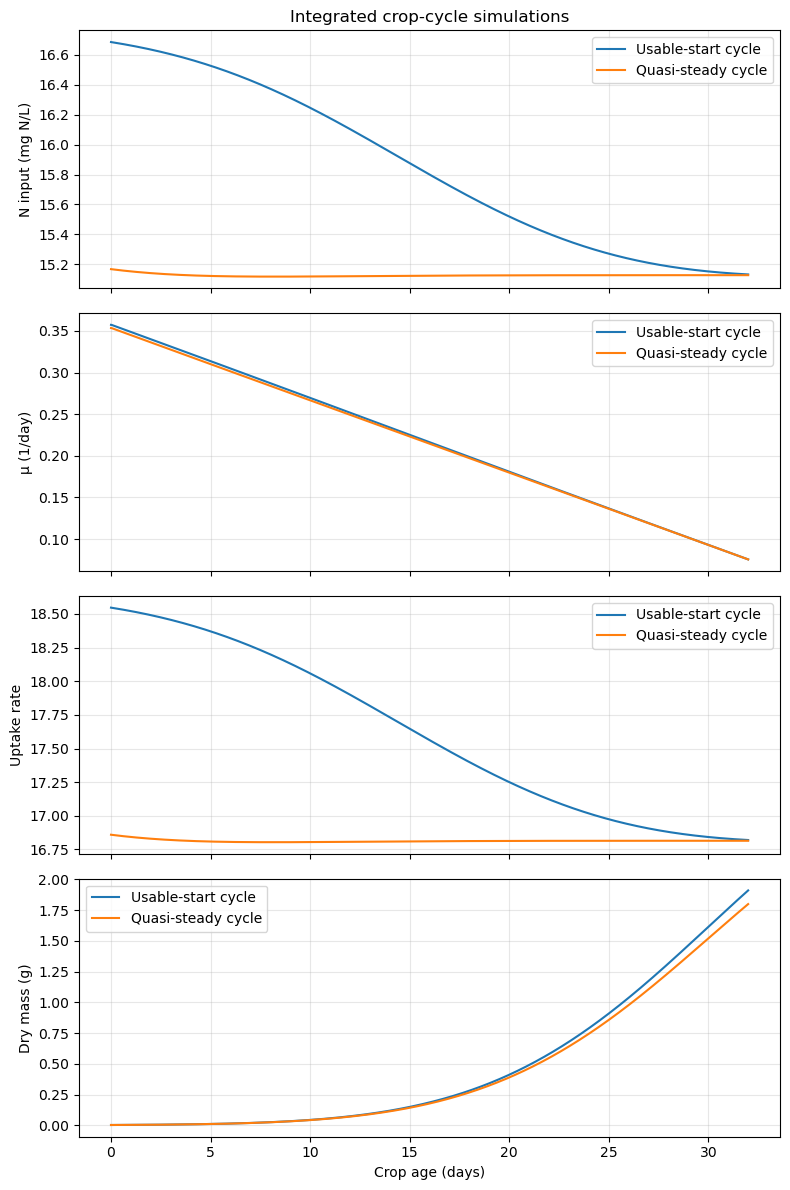

In [15]:
# Integrated plots

fig, axes = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

axes[0].plot(sim_usable["t_crop"], sim_usable["N_input"], label="Usable-start cycle")
axes[0].plot(sim_qs["t_crop"], sim_qs["N_input"], label="Quasi-steady cycle")
axes[0].set_ylabel("N input (mg N/L)")
axes[0].set_title("Integrated crop-cycle simulations")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(sim_usable["t_crop"], sim_usable["mu"], label="Usable-start cycle")
axes[1].plot(sim_qs["t_crop"], sim_qs["mu"], label="Quasi-steady cycle")
axes[1].set_ylabel("μ (1/day)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(sim_usable["t_crop"], sim_usable["U"], label="Usable-start cycle")
axes[2].plot(sim_qs["t_crop"], sim_qs["U"], label="Quasi-steady cycle")
axes[2].set_ylabel("Uptake rate")
axes[2].grid(True, alpha=0.3)

axes[3].plot(sim_usable["t_crop"], sim_usable["DM"], label="Usable-start cycle")
axes[3].plot(sim_qs["t_crop"], sim_qs["DM"], label="Quasi-steady cycle")
axes[3].set_ylabel("Dry mass (g)")
axes[3].set_xlabel("Crop age (days)")
axes[3].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()


## B. All-method comparison

This section compares **all growth methods** under the same upstream-driven nitrogen forcing.
The uptake model remains the same Michaelis–Menten model.


In [17]:
MODEL_DISPLAY = {
    "dynamic": "Dynamic μ",
    "rmnd": "RMND μ",
    "smnd": "SMND μ",
    "liebig": "Liebig minimum Monod",
    "multiplicative": "Multiplicative Monod",
}

growth_models = ["dynamic", "rmnd", "smnd", "liebig", "multiplicative"]

all_methods_usable = {}
all_methods_qs = {}

for model_name in growth_models:
    all_methods_usable[model_name] = simulate_cycle(
        model_name, usable_start, CROP_CYCLE_DAYS, usable_match
    )
    all_methods_qs[model_name] = simulate_cycle(
        model_name, qs_start, CROP_CYCLE_DAYS, qs_match
    )

print("Completed all-method integrated simulations.")

Completed all-method integrated simulations.


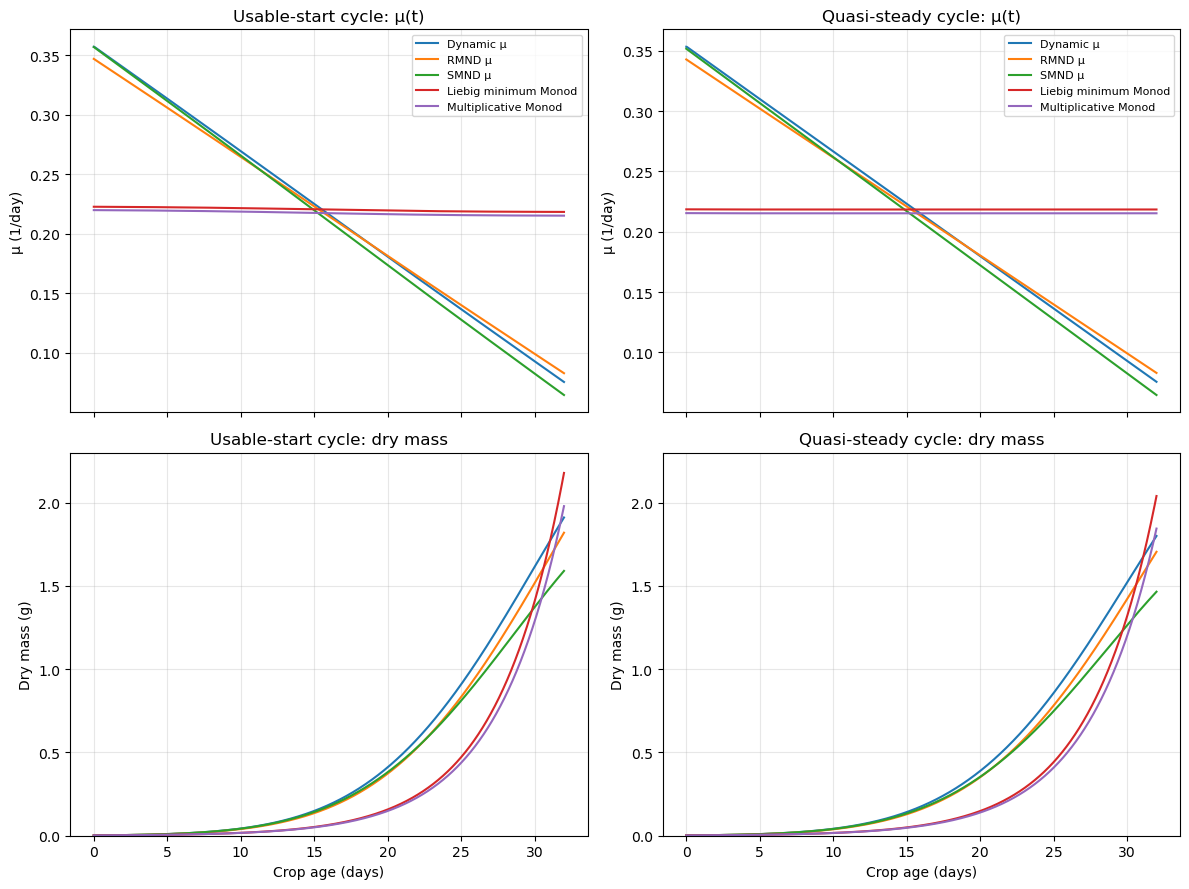

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

# μ(t) for usable cycle
for model_name in growth_models:
    axes[0, 0].plot(
        all_methods_usable[model_name]["t_crop"],
        all_methods_usable[model_name]["mu"],
        label=MODEL_DISPLAY[model_name]
    )
axes[0, 0].set_title("Usable-start cycle: μ(t)")
axes[0, 0].set_ylabel("μ (1/day)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

# DM(t) for usable cycle
for model_name in growth_models:
    axes[1, 0].plot(
        all_methods_usable[model_name]["t_crop"],
        all_methods_usable[model_name]["DM"],
        label=MODEL_DISPLAY[model_name]
    )
axes[1, 0].set_title("Usable-start cycle: dry mass")
axes[1, 0].set_xlabel("Crop age (days)")
axes[1, 0].set_ylabel("Dry mass (g)")
axes[1, 0].set_ylim(0, 2.3)
axes[1, 0].grid(True, alpha=0.3)

# μ(t) for quasi-steady cycle
for model_name in growth_models:
    axes[0, 1].plot(
        all_methods_qs[model_name]["t_crop"],
        all_methods_qs[model_name]["mu"],
        label=MODEL_DISPLAY[model_name]
    )
axes[0, 1].set_title("Quasi-steady cycle: μ(t)")
axes[0, 1].set_ylabel("μ (1/day)")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

# DM(t) for quasi-steady cycle
for model_name in growth_models:
    axes[1, 1].plot(
        all_methods_qs[model_name]["t_crop"],
        all_methods_qs[model_name]["DM"],
        label=MODEL_DISPLAY[model_name]
    )
axes[1, 1].set_title("Quasi-steady cycle: dry mass")
axes[1, 1].set_xlabel("Crop age (days)")
axes[1, 1].set_ylabel("Dry mass (g)")
axes[1, 1].set_ylim(0, 2.3)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
# Save summary tables
summary_rows = []

for cycle_name, sims in [("usable", all_methods_usable), ("quasi_steady", all_methods_qs)]:
    for model_name, sim in sims.items():
        summary_rows.append({
            "cycle": cycle_name,
            "model": model_name,
            "mu_start": float(sim["mu"][0]),
            "mu_end": float(sim["mu"][-1]),
            "DM_start": float(sim["DM"][0]),
            "DM_end": float(sim["DM"][-1]),
            "dDMdt_start": float(sim["dDMdt"][0]),
            "dDMdt_end": float(sim["dDMdt"][-1]),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,cycle,model,mu_start,mu_end,DM_start,DM_end,dDMdt_start,dDMdt_end
0,usable,dynamic,0.357210,0.075608,0.001878,1.910671,0.000671,0.144461
1,usable,rmnd,0.347015,0.082972,0.001878,1.819216,0.000652,0.150944
2,usable,smnd,0.356979,0.064657,0.001878,1.589899,0.000671,0.102797
3,usable,liebig,0.222806,0.218466,0.001878,2.178076,0.000419,0.475836
4,usable,multiplicative,0.219973,0.215320,0.001878,1.978689,0.000413,0.426052
5,quasi_steady,dynamic,0.353363,0.075594,0.001878,1.799555,0.000664,0.136035
6,quasi_steady,rmnd,0.342837,0.082957,0.001878,1.704628,0.000644,0.141411
7,quasi_steady,smnd,0.351718,0.064638,0.001878,1.464967,0.000661,0.094692
8,quasi_steady,liebig,0.218573,0.218451,0.001878,2.039441,0.000411,0.445519
9,quasi_steady,multiplicative,0.215434,0.215304,0.001878,1.844047,0.000405,0.397031


# Sensitivity Analysis & Visualization

Sensitivity analysis completed.


,cycle,model,perturbation,value,mu_start,mu_end,DM_start,DM_end,dDMdt_start,dDMdt_end
0,usable,dynamic,N_scale,0.7,0.341308,0.058527,0.001878,1.125876,0.000641,0.065894
1,usable,rmnd,N_scale,0.7,0.329811,0.064548,0.001878,1.027485,0.000619,0.066322
2,usable,smnd,N_scale,0.7,0.335501,0.041802,0.001878,0.781076,0.000630,0.032650
3,usable,liebig,N_scale,0.7,0.205751,0.200496,0.001878,1.242373,0.000386,0.249091
4,usable,multiplicative,N_scale,0.7,0.201779,0.196223,0.001878,1.088451,0.000379,0.213579



Local sensitivity indices for N-scale:


,cycle,model,perturbation,value,metric,sensitivity_index
0,quasi_steady,dynamic,N_scale,0.70,DM_end,1.403845
1,quasi_steady,dynamic,N_scale,0.85,DM_end,1.378835
2,quasi_steady,dynamic,N_scale,1.00,DM_end,0.000000
3,quasi_steady,dynamic,N_scale,1.15,DM_end,1.295623
4,quasi_steady,dynamic,N_scale,1.30,DM_end,1.248165
5,quasi_steady,rmnd,N_scale,0.70,DM_end,1.485046
6,quasi_steady,rmnd,N_scale,0.85,DM_end,1.478580
7,quasi_steady,rmnd,N_scale,1.00,DM_end,0.000000
8,quasi_steady,rmnd,N_scale,1.15,DM_end,1.419350
9,quasi_steady,rmnd,N_scale,1.30,DM_end,1.378844



Local sensitivity indices for start-time shift:


,cycle,model,perturbation,value,metric,sensitivity_index
0,quasi_steady,dynamic,start_shift_days,-5.0,DM_end,-0.000249
1,quasi_steady,dynamic,start_shift_days,-2.0,DM_end,-0.000090
2,quasi_steady,dynamic,start_shift_days,0.0,DM_end,0.000000
3,quasi_steady,dynamic,start_shift_days,2.0,DM_end,-0.000072
4,quasi_steady,dynamic,start_shift_days,5.0,DM_end,-0.000033
5,quasi_steady,rmnd,start_shift_days,-5.0,DM_end,-0.000270
6,quasi_steady,rmnd,start_shift_days,-2.0,DM_end,-0.000097
7,quasi_steady,rmnd,start_shift_days,0.0,DM_end,0.000000
8,quasi_steady,rmnd,start_shift_days,2.0,DM_end,-0.000078
9,quasi_steady,rmnd,start_shift_days,5.0,DM_end,-0.000036


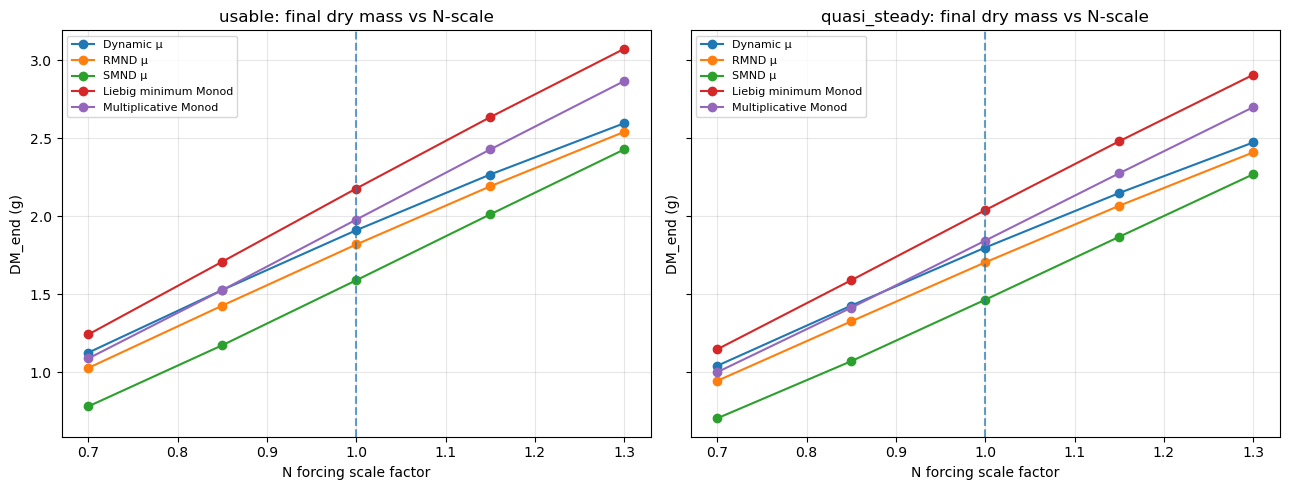

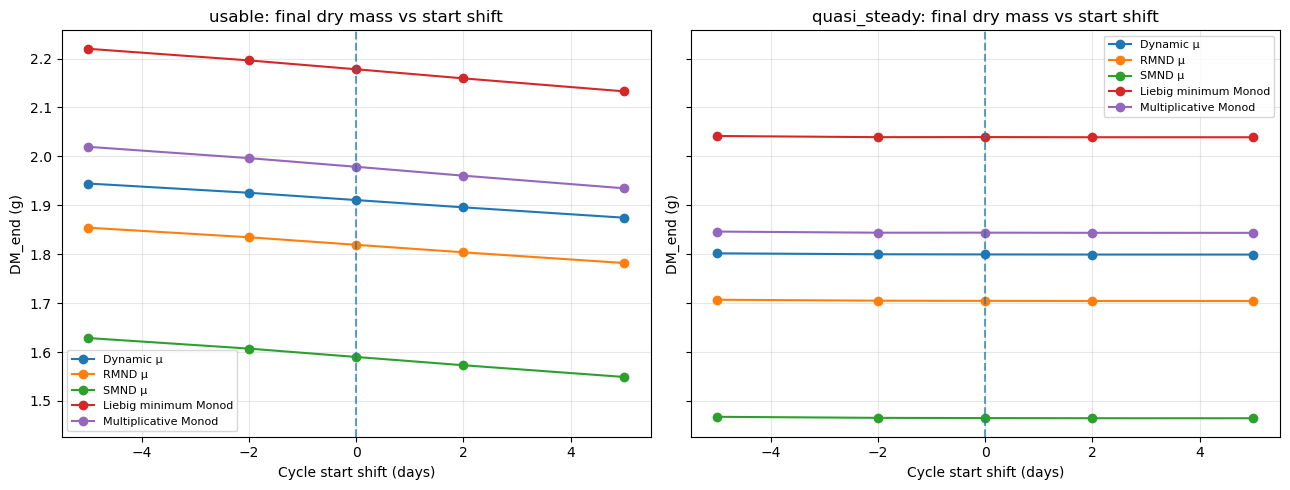

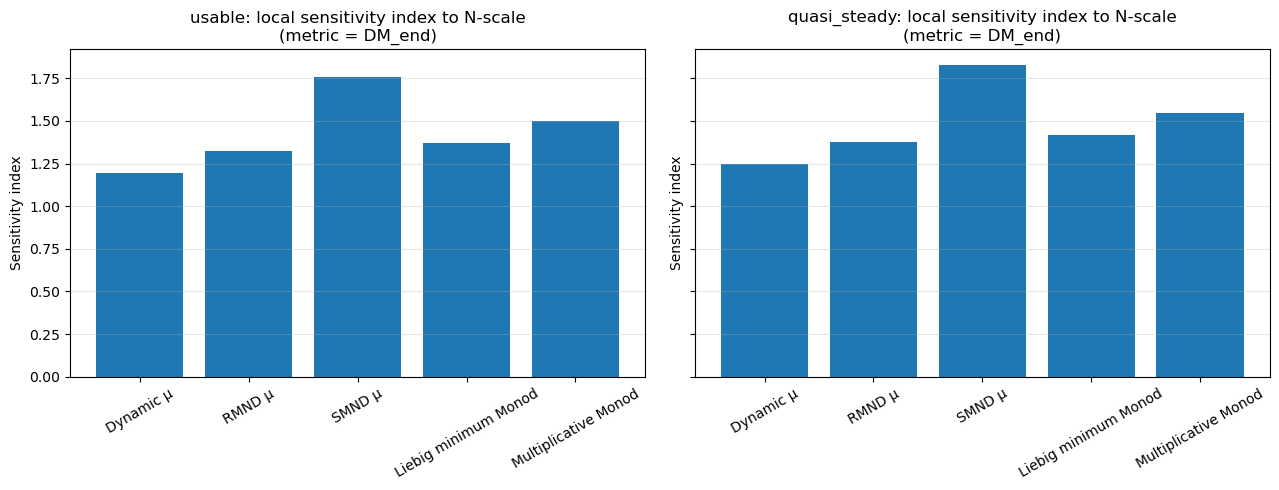

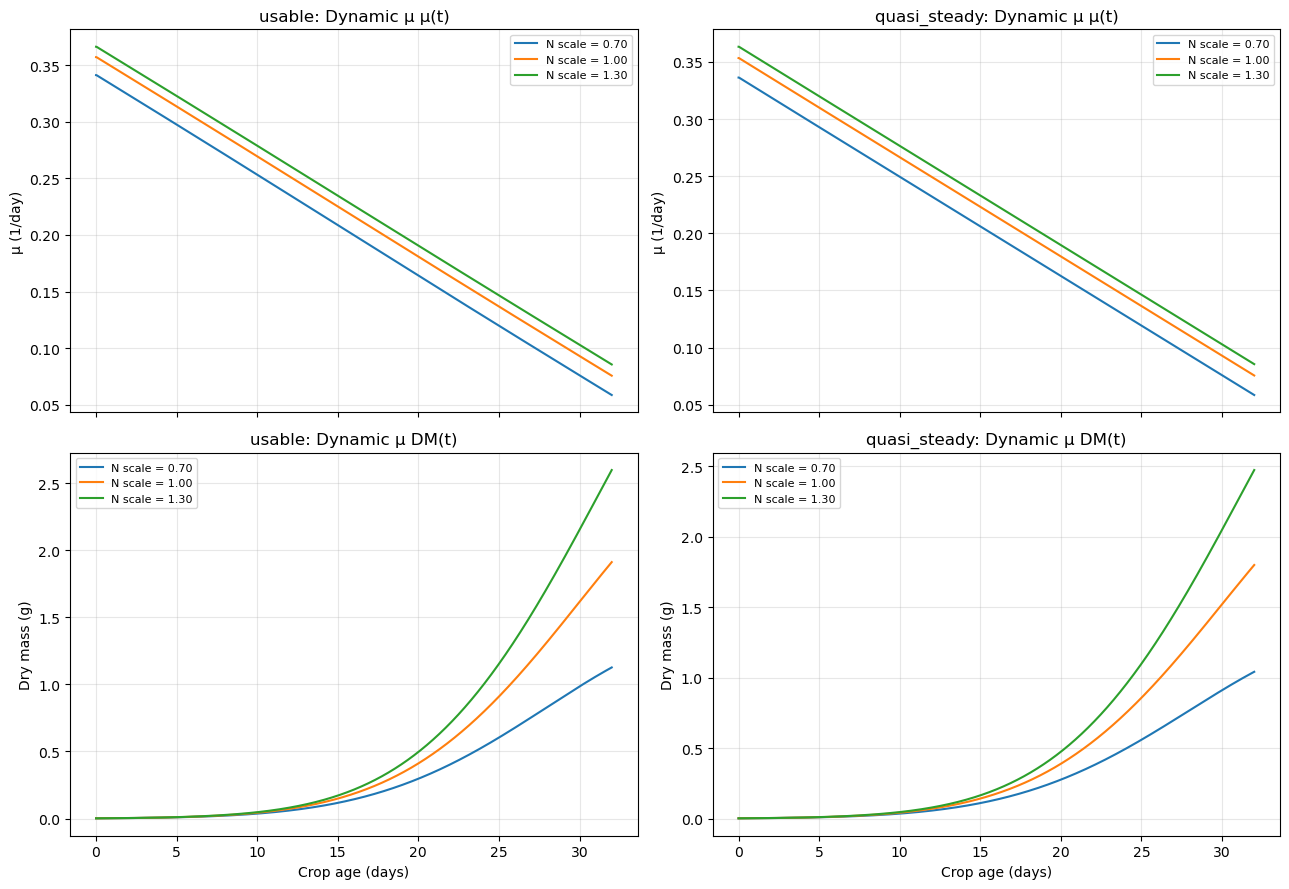


Saved files:
  - sensitivity_results.csv
  - sensitivity_index_Nscale.csv
  - sensitivity_index_startshift.csv


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# configuration
N_SCALE_FACTORS = [0.70, 0.85, 1.00, 1.15, 1.30] # scale total N forcing
START_SHIFT_DAYS = [-5.0, -2.0, 0.0, 2.0, 5.0] # shift cycle start time
SENS_TARGET_METRIC = "DM_end" 


def summarize_single_sim(sim, cycle_name, model_name, perturb_name, perturb_value):
    """
    Extract summary metrics from one simulate_cycle(...) result.
    Assumes sim dict contains:
      sim["mu"], sim["DM"], sim["dDMdt"] (or can be derived), sim["t_crop"]
    """
    row = {
        "cycle": cycle_name,
        "model": model_name,
        "perturbation": perturb_name,
        "value": float(perturb_value),
        "mu_start": float(sim["mu"][0]),
        "mu_end": float(sim["mu"][-1]),
        "DM_start": float(sim["DM"][0]),
        "DM_end": float(sim["DM"][-1]),
    }

    if "dDMdt" in sim:
        row["dDMdt_start"] = float(sim["dDMdt"][0])
        row["dDMdt_end"] = float(sim["dDMdt"][-1])
    else:
        # fallback if dDMdt is not explicitly stored
        dm = np.asarray(sim["DM"], dtype=float)
        tt = np.asarray(sim["t_crop"], dtype=float)
        dmdt = np.gradient(dm, tt)
        row["dDMdt_start"] = float(dmdt[0])
        row["dDMdt_end"] = float(dmdt[-1])

    return row


def run_sensitivity_with_scaled_totalN(scale_factor, cycle_name, start_time, duration, match_row):
    """
    Temporarily scale global N_total forcing, run all growth models, then restore.
    This assumes simulate_cycle() internally uses the global N_total array.
    """
    global N_total

    original_N_total = N_total.copy()
    N_total = original_N_total * scale_factor

    rows = []
    sims = {}

    try:
        for model_name in growth_models:
            sim = simulate_cycle(model_name, start_time, duration, match_row)
            sims[model_name] = sim
            rows.append(
                summarize_single_sim(
                    sim=sim,
                    cycle_name=cycle_name,
                    model_name=model_name,
                    perturb_name="N_scale",
                    perturb_value=scale_factor
                )
            )
    finally:
        N_total = original_N_total

    return pd.DataFrame(rows), sims


def run_sensitivity_with_shifted_start(start_shift, cycle_name, base_start, duration, match_row):
    """
    Shift cycle start time, keep upstream forcing unchanged.
    """
    shifted_start = float(base_start + start_shift)

    # clamp to valid range so the crop window stays inside upstream timeline
    t_min = float(np.min(t_up))
    t_max = float(np.max(t_up))
    shifted_start = max(t_min, min(shifted_start, t_max - duration))

    rows = []
    sims = {}

    for model_name in growth_models:
        sim = simulate_cycle(model_name, shifted_start, duration, match_row)
        sims[model_name] = sim
        rows.append(
            summarize_single_sim(
                sim=sim,
                cycle_name=cycle_name,
                model_name=model_name,
                perturb_name="start_shift_days",
                perturb_value=start_shift
            )
        )

    return pd.DataFrame(rows), sims


def compute_local_sensitivity_index(df, perturb_name, metric="DM_end"):
    """
    Compute normalized local sensitivity around baseline value=1.0 for N_scale
    or value=0.0 for start_shift_days.

    Sensitivity index:
        S = (ΔY / Y0) / (ΔX / X0)         for N_scale
        S = (ΔY / Y0) / ΔX                for start shift
    """
    out_rows = []

    for cycle_name in sorted(df["cycle"].unique()):
        for model_name in growth_models:
            sub = df[(df["cycle"] == cycle_name) &
                     (df["model"] == model_name) &
                     (df["perturbation"] == perturb_name)].copy()

            if perturb_name == "N_scale":
                base = sub[np.isclose(sub["value"], 1.0)]
                if len(base) == 0:
                    continue
                y0 = float(base.iloc[0][metric])

                for _, r in sub.iterrows():
                    x = float(r["value"])
                    y = float(r[metric])

                    if np.isclose(x, 1.0):
                        s = 0.0
                    else:
                        s = ((y - y0) / y0) / ((x - 1.0) / 1.0)

                    out_rows.append({
                        "cycle": cycle_name,
                        "model": model_name,
                        "perturbation": perturb_name,
                        "value": x,
                        "metric": metric,
                        "sensitivity_index": s
                    })

            elif perturb_name == "start_shift_days":
                base = sub[np.isclose(sub["value"], 0.0)]
                if len(base) == 0:
                    continue
                y0 = float(base.iloc[0][metric])

                for _, r in sub.iterrows():
                    x = float(r["value"])
                    y = float(r[metric])

                    if np.isclose(x, 0.0):
                        s = 0.0
                    else:
                        s = ((y - y0) / y0) / x

                    out_rows.append({
                        "cycle": cycle_name,
                        "model": model_name,
                        "perturbation": perturb_name,
                        "value": x,
                        "metric": metric,
                        "sensitivity_index": s
                    })

    return pd.DataFrame(out_rows)


# Run sensitivity analyses
sens_rows_all = []
sens_sims = {
    "usable": {"N_scale": {}, "start_shift_days": {}},
    "quasi_steady": {"N_scale": {}, "start_shift_days": {}},
}

# A. total-N forcing amplitude sensitivity
for sf in N_SCALE_FACTORS:
    df_u, sims_u = run_sensitivity_with_scaled_totalN(
        scale_factor=sf,
        cycle_name="usable",
        start_time=usable_start,
        duration=CROP_CYCLE_DAYS,
        match_row=usable_match
    )
    df_q, sims_q = run_sensitivity_with_scaled_totalN(
        scale_factor=sf,
        cycle_name="quasi_steady",
        start_time=qs_start,
        duration=CROP_CYCLE_DAYS,
        match_row=qs_match
    )
    sens_rows_all.append(df_u)
    sens_rows_all.append(df_q)
    sens_sims["usable"]["N_scale"][sf] = sims_u
    sens_sims["quasi_steady"]["N_scale"][sf] = sims_q

# B. cycle start-time sensitivity
for ds in START_SHIFT_DAYS:
    df_u, sims_u = run_sensitivity_with_shifted_start(
        start_shift=ds,
        cycle_name="usable",
        base_start=usable_start,
        duration=CROP_CYCLE_DAYS,
        match_row=usable_match
    )
    df_q, sims_q = run_sensitivity_with_shifted_start(
        start_shift=ds,
        cycle_name="quasi_steady",
        base_start=qs_start,
        duration=CROP_CYCLE_DAYS,
        match_row=qs_match
    )
    sens_rows_all.append(df_u)
    sens_rows_all.append(df_q)
    sens_sims["usable"]["start_shift_days"][ds] = sims_u
    sens_sims["quasi_steady"]["start_shift_days"][ds] = sims_q

sensitivity_df = pd.concat(sens_rows_all, ignore_index=True)

print("Sensitivity analysis completed.")
display(sensitivity_df.head())


# compute sensitivity indices

sens_idx_N = compute_local_sensitivity_index(
    sensitivity_df, perturb_name="N_scale", metric=SENS_TARGET_METRIC
)
sens_idx_start = compute_local_sensitivity_index(
    sensitivity_df, perturb_name="start_shift_days", metric=SENS_TARGET_METRIC
)

print("\nLocal sensitivity indices for N-scale:")
display(sens_idx_N)

print("\nLocal sensitivity indices for start-time shift:")
display(sens_idx_start)



# DM_end vs N-scale

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, cycle_name in zip(axes, ["usable", "quasi_steady"]):
    sub = sensitivity_df[
        (sensitivity_df["cycle"] == cycle_name) &
        (sensitivity_df["perturbation"] == "N_scale")
    ]

    for model_name in growth_models:
        mm = sub[sub["model"] == model_name].sort_values("value")
        ax.plot(mm["value"], mm["DM_end"], marker="o", label=MODEL_DISPLAY.get(model_name, model_name))

    ax.axvline(1.0, linestyle="--", alpha=0.7)
    ax.set_title(f"{cycle_name}: final dry mass vs N-scale")
    ax.set_xlabel("N forcing scale factor")
    ax.set_ylabel("DM_end (g)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig1_DM_vs_Nscale.png", dpi=300, bbox_inches='tight')
plt.show()


# DM_end vs start shift

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, cycle_name in zip(axes, ["usable", "quasi_steady"]):
    sub = sensitivity_df[
        (sensitivity_df["cycle"] == cycle_name) &
        (sensitivity_df["perturbation"] == "start_shift_days")
    ]

    for model_name in growth_models:
        mm = sub[sub["model"] == model_name].sort_values("value")
        ax.plot(mm["value"], mm["DM_end"], marker="o", label=MODEL_DISPLAY.get(model_name, model_name))

    ax.axvline(0.0, linestyle="--", alpha=0.7)
    ax.set_title(f"{cycle_name}: final dry mass vs start shift")
    ax.set_xlabel("Cycle start shift (days)")
    ax.set_ylabel("DM_end (g)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig2_DM_vs_startshift.png", dpi=300, bbox_inches='tight')
plt.show()


# bar chart of local sensitivity index to N forcing
# Use the largest positive perturbation for a simple comparison bar chart
plot_sub = sens_idx_N[np.isclose(sens_idx_N["value"], max(N_SCALE_FACTORS))].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, cycle_name in zip(axes, ["usable", "quasi_steady"]):
    mm = plot_sub[plot_sub["cycle"] == cycle_name].copy()
    mm = mm.set_index("model").reindex(growth_models).reset_index()

    ax.bar(
        [MODEL_DISPLAY.get(m, m) for m in mm["model"]],
        mm["sensitivity_index"]
    )
    ax.set_title(f"{cycle_name}: local sensitivity index to N-scale\n(metric = {SENS_TARGET_METRIC})")
    ax.set_ylabel("Sensitivity index")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig3_sensitivity_index.png", dpi=300, bbox_inches='tight')
plt.show()



# example trajectory comparison under low/base/high N forcing

example_factors = [min(N_SCALE_FACTORS), 1.0, max(N_SCALE_FACTORS)]
example_model = "dynamic"

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

for j, cycle_name in enumerate(["usable", "quasi_steady"]):
    ax_mu = axes[0, j]
    ax_dm = axes[1, j]

    for sf in example_factors:
        sim = sens_sims[cycle_name]["N_scale"][sf][example_model]
        ax_mu.plot(sim["t_crop"], sim["mu"], label=f"N scale = {sf:.2f}")
        ax_dm.plot(sim["t_crop"], sim["DM"], label=f"N scale = {sf:.2f}")

    ax_mu.set_title(f"{cycle_name}: {MODEL_DISPLAY.get(example_model, example_model)} μ(t)")
    ax_mu.set_ylabel("μ (1/day)")
    ax_mu.grid(True, alpha=0.3)
    ax_mu.legend(fontsize=8)

    ax_dm.set_title(f"{cycle_name}: {MODEL_DISPLAY.get(example_model, example_model)} DM(t)")
    ax_dm.set_xlabel("Crop age (days)")
    ax_dm.set_ylabel("Dry mass (g)")
    ax_dm.grid(True, alpha=0.3)
    ax_dm.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig4_dynamic_trajectories.png", dpi=300, bbox_inches='tight')
plt.show()


sensitivity_df.to_csv("sensitivity_results.csv", index=False)
sens_idx_N.to_csv("sensitivity_index_Nscale.csv", index=False)
sens_idx_start.to_csv("sensitivity_index_startshift.csv", index=False)

print("\nSaved files:")
print("  - sensitivity_results.csv")
print("  - sensitivity_index_Nscale.csv")
print("  - sensitivity_index_startshift.csv")

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

MODEL_DISPLAY = {
    "dynamic": "Dynamic-μ",
    "rmnd": "RMND-μ",
    "smnd": "SMND-μ",
    "liebig": "Liebig minimum Monod",
    "multiplicative": "Multiplicative Monod",
}

def extract_time_dm(sim):
    if not isinstance(sim, dict):
        raise TypeError("Simulation result must be a dict.")

    t_candidates = ["t_crop", "t", "time", "days"]
    dm_candidates = ["DM", "dm", "biomass", "Biomass", "X"]

    t_key = next((k for k in t_candidates if k in sim), None)
    dm_key = next((k for k in dm_candidates if k in sim), None)

    if t_key is None:
        raise KeyError(f"Could not find time key in simulation dict. Tried: {t_candidates}")
    if dm_key is None:
        raise KeyError(f"Could not find biomass/DM key in simulation dict. Tried: {dm_candidates}")

    t = np.asarray(sim[t_key], dtype=float)
    dm = np.asarray(sim[dm_key], dtype=float)
    return t, dm

def extract_series(sim, candidates, name="series"):
    if not isinstance(sim, dict):
        raise TypeError("Simulation result must be a dict.")
    key = next((k for k in candidates if k in sim), None)
    if key is None:
        raise KeyError(f"Could not find {name}. Tried: {candidates}")
    return np.asarray(sim[key], dtype=float)

def get_dynamic_sims():
    if "all_methods_usable" in globals() and "all_methods_qs" in globals():
        return all_methods_usable["dynamic"], all_methods_qs["dynamic"]

    usable_candidates = ["dynamic_usable_sim", "sim_dynamic_usable", "usable_dynamic_sim"]
    qs_candidates = ["dynamic_qs_sim", "sim_dynamic_qs", "qs_dynamic_sim"]

    usable_sim = None
    qs_sim = None

    for name in usable_candidates:
        if name in globals():
            usable_sim = globals()[name]
            break

    for name in qs_candidates:
        if name in globals():
            qs_sim = globals()[name]
            break

    if usable_sim is None or qs_sim is None:
        raise NameError(
            "Could not find Dynamic-μ usable / quasi-steady simulations. "
            "Please check your variable names or edit get_dynamic_sims()."
        )

    return usable_sim, qs_sim

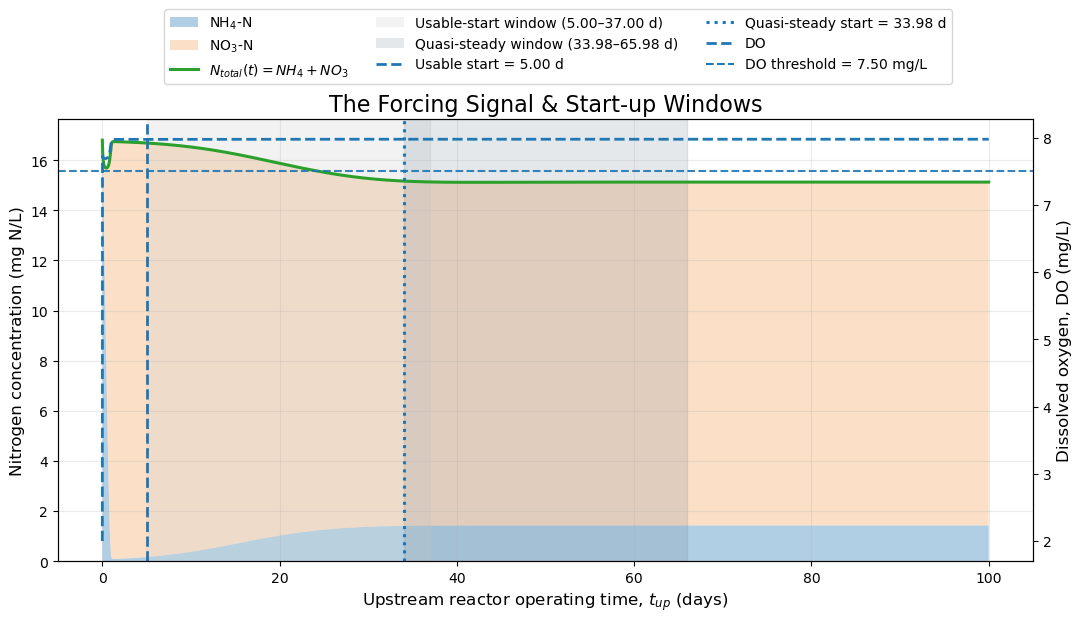

In [72]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# The Forcing Signal & Start-up Windows

fig, ax1 = plt.subplots(figsize=(12.5, 6.5), constrained_layout=False)
ax2 = ax1.twinx()

nh4_color = "tab:blue"
no3_color = "sandybrown"
ntotal_color = "tab:green"
do_color = "tab:blue"

usable_span_color = "lightgray"
qs_span_color = "slategray"

# stackplot
ax1.stackplot(
    t_up,
    NH4,
    NO3,
    colors=[nh4_color, no3_color],
    alpha=0.35
)

# total N line
ax1.plot(
    t_up,
    N_total,
    color=ntotal_color,
    linewidth=2.2
)

# windows
ax1.axvspan(
    usable_start,
    usable_start + CROP_CYCLE_DAYS,
    color=usable_span_color,
    alpha=0.28
)

ax1.axvspan(
    qs_start,
    qs_start + CROP_CYCLE_DAYS,
    color=qs_span_color,
    alpha=0.18
)

# start lines
ax1.axvline(
    usable_start,
    color="tab:blue",
    linestyle="--",
    linewidth=2.0
)
ax1.axvline(
    qs_start,
    color="tab:blue",
    linestyle=":",
    linewidth=2.2
)

ax1.set_xlabel(r"Upstream reactor operating time, $t_{up}$ (days)", fontsize=12)
ax1.set_ylabel("Nitrogen concentration (mg N/L)", fontsize=12)
ax1.set_title("The Forcing Signal & Start-up Windows", fontsize=16)
ax1.grid(True, alpha=0.25)

# Right axis: DO
ax2.plot(
    t_up,
    DO,
    color=do_color,
    linestyle="--",
    linewidth=2.0
)

ax2.axhline(
    USE_DO_MIN,
    color=do_color,
    linestyle="--",
    linewidth=1.5,
    alpha=0.9
)

ax2.set_ylabel("Dissolved oxygen, DO (mg/L)", fontsize=12)

# Build a cleaner custom legend 
legend_handles = [
    Patch(facecolor=nh4_color, alpha=0.35, label=r"NH$_4$-N"),
    Patch(facecolor=no3_color, alpha=0.35, label=r"NO$_3$-N"),
    Line2D([0], [0], color=ntotal_color, lw=2.2, label=r"$N_{total}(t)=NH_4+NO_3$"),
    Patch(facecolor=usable_span_color, alpha=0.28,
          label=f"Usable-start window ({usable_start:.2f}–{usable_start + CROP_CYCLE_DAYS:.2f} d)"),
    Patch(facecolor=qs_span_color, alpha=0.18,
          label=f"Quasi-steady window ({qs_start:.2f}–{qs_start + CROP_CYCLE_DAYS:.2f} d)"),
    Line2D([0], [0], color="tab:blue", lw=2.0, linestyle="--",
           label=f"Usable start = {usable_start:.2f} d"),
    Line2D([0], [0], color="tab:blue", lw=2.2, linestyle=":",
           label=f"Quasi-steady start = {qs_start:.2f} d"),
    Line2D([0], [0], color=do_color, lw=2.0, linestyle="--", label="DO"),
    Line2D([0], [0], color=do_color, lw=1.5, linestyle="--",
           label=f"DO threshold = {USE_DO_MIN:.2f} mg/L"),
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=True,
    fontsize=10
)


plt.subplots_adjust(top=0.80, right=0.88, left=0.10, bottom=0.12)
plt.savefig("fig_forcing_signal_and_startup_windows.png")

# plt.show()

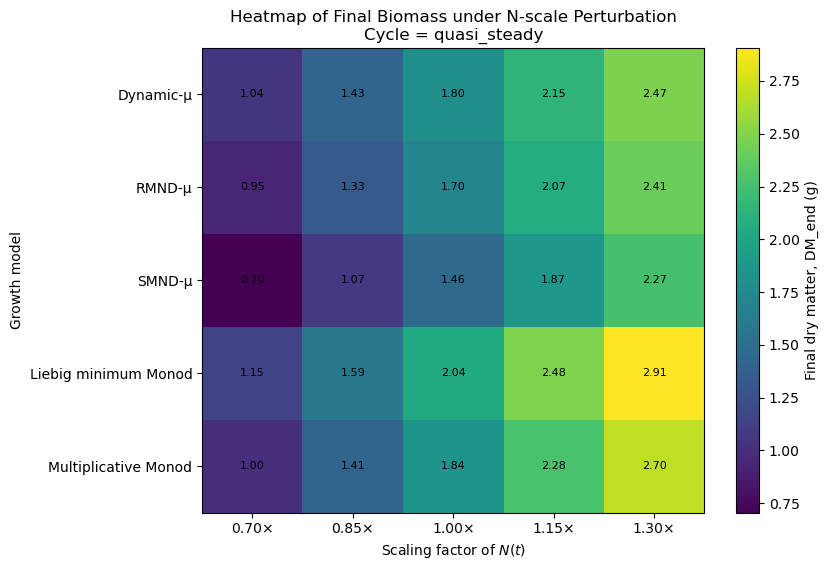

In [73]:
# Heatmap: model × N-scale, colored by DM_end
target_cycle = "quasi_steady"

heat_df = sensitivity_df[
    (sensitivity_df["cycle"] == target_cycle) &
    (sensitivity_df["perturbation"] == "N_scale")
].copy()

heat_df["model_display"] = heat_df["model"].map(lambda m: MODEL_DISPLAY.get(m, m))

model_order = growth_models
model_display_order = [MODEL_DISPLAY.get(m, m) for m in model_order]

pivot = heat_df.pivot_table(
    index="model_display",
    columns="value",
    values="DM_end",
    aggfunc="mean"
)

pivot = pivot.reindex(model_display_order)
pivot = pivot.reindex(sorted(pivot.columns), axis=1)

fig, ax = plt.subplots(figsize=(8.5, 5.8))

im = ax.imshow(
    pivot.values,
    aspect="auto",
    origin="upper"
)

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([f"{x:.2f}×" for x in pivot.columns])
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel(r"Scaling factor of $N(t)$")
ax.set_ylabel("Growth model")
ax.set_title(f"Heatmap of Final Biomass under N-scale Perturbation\nCycle = {target_cycle}")


for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Final dry matter, DM_end (g)")

plt.tight_layout()
plt.savefig("fig_heatmap_model_by_Nscale_DMend.png", dpi=300, bbox_inches="tight")
plt.show()

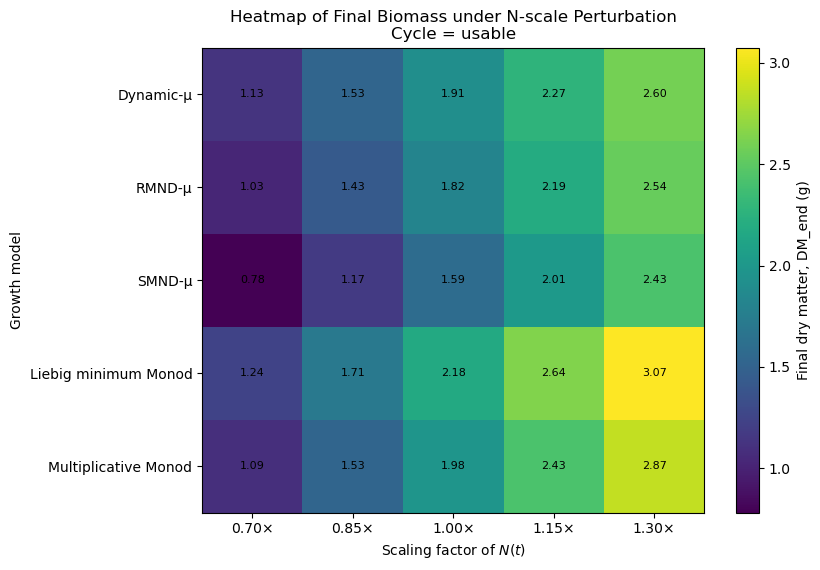

In [74]:
# Heatmap: model × N-scale, colored by DM_end
target_cycle = "usable"

heat_df = sensitivity_df[
    (sensitivity_df["cycle"] == target_cycle) &
    (sensitivity_df["perturbation"] == "N_scale")
].copy()

heat_df["model_display"] = heat_df["model"].map(lambda m: MODEL_DISPLAY.get(m, m))

model_order = growth_models
model_display_order = [MODEL_DISPLAY.get(m, m) for m in model_order]

pivot = heat_df.pivot_table(
    index="model_display",
    columns="value",
    values="DM_end",
    aggfunc="mean"
)

pivot = pivot.reindex(model_display_order)
pivot = pivot.reindex(sorted(pivot.columns), axis=1)

fig, ax = plt.subplots(figsize=(8.5, 5.8))

im = ax.imshow(
    pivot.values,
    aspect="auto",
    origin="upper"
)

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([f"{x:.2f}×" for x in pivot.columns])
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel(r"Scaling factor of $N(t)$")
ax.set_ylabel("Growth model")
ax.set_title(f"Heatmap of Final Biomass under N-scale Perturbation\nCycle = {target_cycle}")


for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Final dry matter, DM_end (g)")

plt.tight_layout()
plt.savefig("fig_heatmap_model_by_Nscale_DMend.png", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
summary_df.to_csv(OUTPUT_DIR / "integration_growth_method_summary.csv", index=False)
print("Saved outputs to:", OUTPUT_DIR)

NameError: name 'OUTPUT_DIR' is not defined

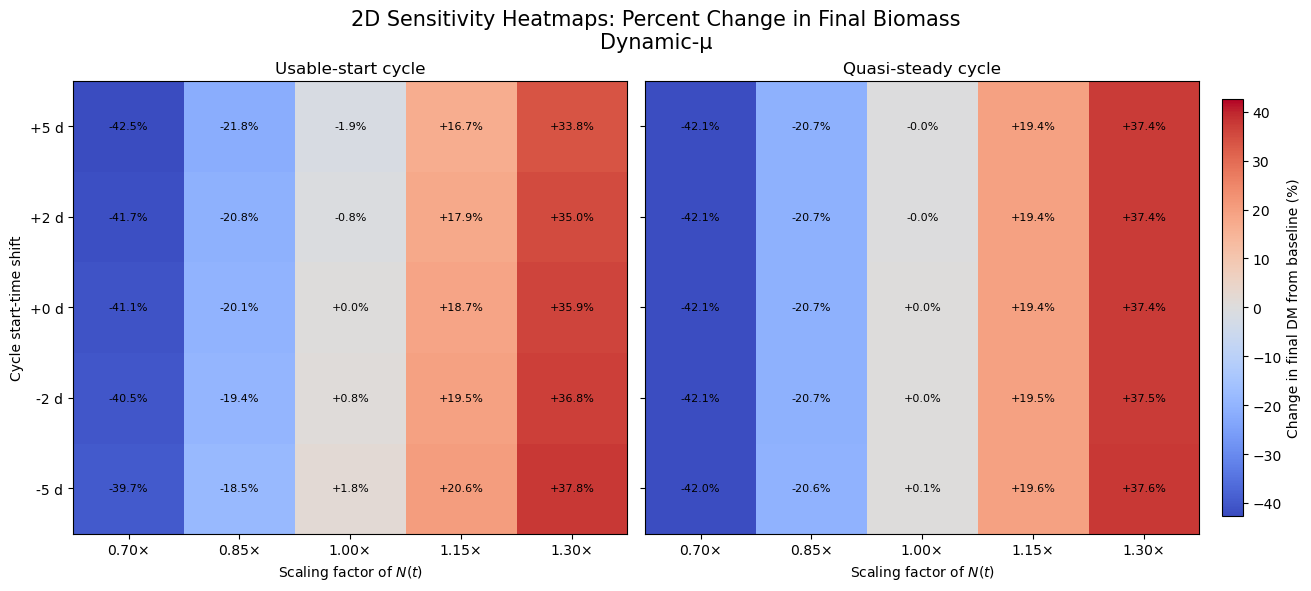

In [78]:
# heatmaps showing percent change from baseline
# usable vs quasi_steady

import numpy as np
import matplotlib.pyplot as plt

target_model = "dynamic"
target_metric = "DM_end"

cycles_to_plot = ["usable", "quasi_steady"]
cycle_titles = {
    "usable": "Usable-start cycle",
    "quasi_steady": "Quasi-steady cycle"
}

pivots_pct = {}

for cycle_name in cycles_to_plot:
    df = full_factorial_df[
        (full_factorial_df["cycle"] == cycle_name) &
        (full_factorial_df["model"] == target_model)
    ].copy()

    baseline_row = df[
        np.isclose(df["N_scale"], 1.0) &
        np.isclose(df["start_shift_days"], 0.0)
    ]

    if len(baseline_row) == 0:
        raise ValueError(f"No baseline found for {cycle_name}, {target_model}")

    baseline = float(baseline_row.iloc[0][target_metric])

    df["pct_change"] = (df[target_metric] - baseline) / baseline * 100.0

    pivot = df.pivot_table(
        index="start_shift_days",
        columns="N_scale",
        values="pct_change",
        aggfunc="mean"
    )

    pivot = pivot.sort_index(axis=0).sort_index(axis=1)
    pivots_pct[cycle_name] = pivot

# symmetric color scale around zero
abs_max = max(np.nanmax(np.abs(p.values)) for p in pivots_pct.values())

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5.8),
    sharey=True,
    constrained_layout=True
)

ims = []

for ax, cycle_name in zip(axes, cycles_to_plot):
    pivot = pivots_pct[cycle_name]

    im = ax.imshow(
        pivot.values,
        aspect="auto",
        origin="lower",
        vmin=-abs_max,
        vmax=abs_max,
        cmap="coolwarm"
    )
    ims.append(im)

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([f"{x:.2f}×" for x in pivot.columns])

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f"{x:+.0f} d" for x in pivot.index])

    ax.set_xlabel(r"Scaling factor of $N(t)$")
    ax.set_title(cycle_titles.get(cycle_name, cycle_name))

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            ax.text(
                j, i,
                f"{val:+.1f}%",
                ha="center",
                va="center",
                fontsize=8
            )

axes[0].set_ylabel("Cycle start-time shift")

fig.suptitle(
    f"2D Sensitivity Heatmaps: Percent Change in Final Biomass\n"
    f"{MODEL_DISPLAY.get(target_model, target_model)}",
    fontsize=15
)

cbar = fig.colorbar(
    ims[0],
    ax=axes,
    shrink=0.92,
    pad=0.02
)
cbar.set_label("Change in final DM from baseline (%)")

plt.savefig(
    "fig_2D_heatmap_percent_change_usable_vs_quasi_steady.png",
    dpi=300,
    bbox_inches="tight"
)

# plt.show()

,cycle,model,N_scale_effect_range,start_shift_effect_range,effect_ratio_N_over_shift
0,usable,dynamic,1.470487,0.067541,21.771896
1,usable,rmnd,1.513477,0.069805,21.681437
2,usable,smnd,1.647058,0.077185,21.339180
3,usable,liebig,1.830886,0.084441,21.682546
4,usable,multiplicative,1.777984,0.082482,21.555913
5,quasi_steady,dynamic,1.431799,0.002443,586.112900
6,quasi_steady,rmnd,1.464663,0.002505,584.640509
7,quasi_steady,smnd,1.564712,0.002828,553.206531
8,quasi_steady,liebig,1.759905,0.002482,709.065863
9,quasi_steady,multiplicative,1.698860,0.002474,686.599269


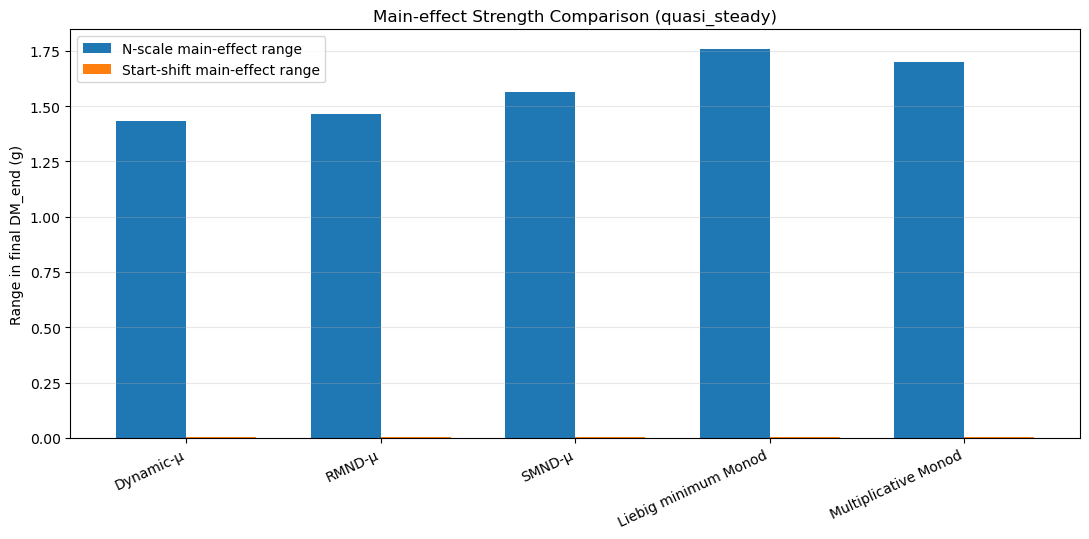

In [88]:
# N-scale effect vs start-shift effect

effect_rows = []

for cycle_name in ["usable", "quasi_steady"]:
    for model_name in growth_models:
        df = full_factorial_df[
            (full_factorial_df["cycle"] == cycle_name) &
            (full_factorial_df["model"] == model_name)
        ].copy()

        # Mean DM_end at each N_scale, averaged across start shifts
        n_effect_curve = df.groupby("N_scale")["DM_end"].mean()
        n_effect_range = n_effect_curve.max() - n_effect_curve.min()

        # Mean DM_end at each start shift, averaged across N_scale
        shift_effect_curve = df.groupby("start_shift_days")["DM_end"].mean()
        shift_effect_range = shift_effect_curve.max() - shift_effect_curve.min()

        effect_rows.append({
            "cycle": cycle_name,
            "model": model_name,
            "N_scale_effect_range": n_effect_range,
            "start_shift_effect_range": shift_effect_range,
            "effect_ratio_N_over_shift": n_effect_range / shift_effect_range if shift_effect_range != 0 else np.inf
        })

effect_df = pd.DataFrame(effect_rows)

display(effect_df)
effect_df.to_csv("main_effect_strength_summary.csv", index=False)


# Plot main-effect strength comparison

plot_cycle = "quasi_steady"

plot_df = effect_df[effect_df["cycle"] == plot_cycle].copy()
plot_df = plot_df.set_index("model").reindex(growth_models).reset_index()

labels = [MODEL_DISPLAY.get(m, m) for m in plot_df["model"]]
x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.bar(
    x - width / 2,
    plot_df["N_scale_effect_range"],
    width,
    label="N-scale main-effect range"
)

ax.bar(
    x + width / 2,
    plot_df["start_shift_effect_range"],
    width,
    label="Start-shift main-effect range"
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Range in final DM_end (g)")
ax.set_title(f"Main-effect Strength Comparison ({plot_cycle})")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("fig_main_effect_strength_comparison_quasi.png", dpi=300, bbox_inches="tight")
plt.show()



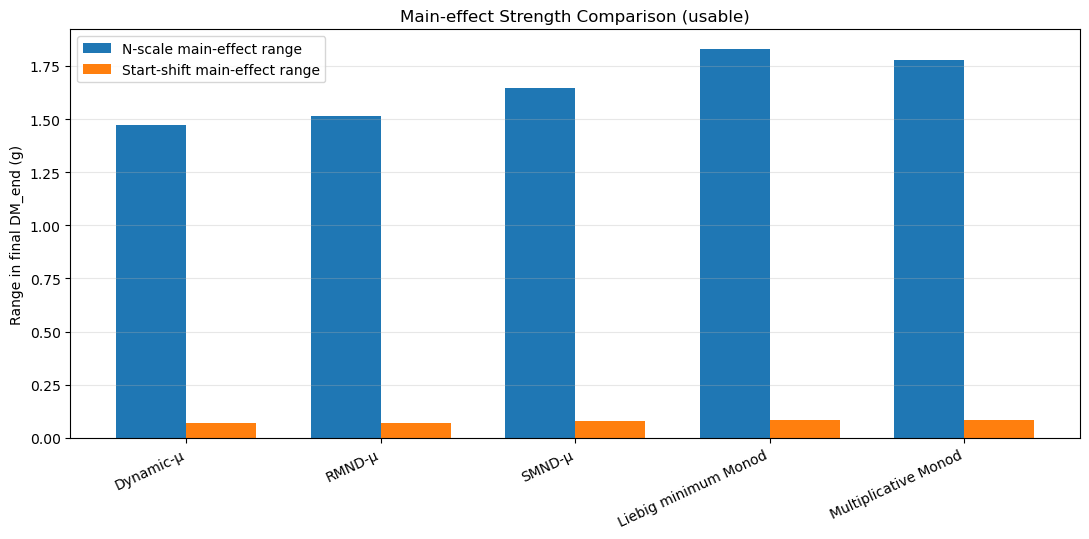

In [90]:
plot_cycle = "usable"

plot_df = effect_df[effect_df["cycle"] == plot_cycle].copy()
plot_df = plot_df.set_index("model").reindex(growth_models).reset_index()

labels = [MODEL_DISPLAY.get(m, m) for m in plot_df["model"]]
x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.bar(
    x - width / 2,
    plot_df["N_scale_effect_range"],
    width,
    label="N-scale main-effect range"
)

ax.bar(
    x + width / 2,
    plot_df["start_shift_effect_range"],
    width,
    label="Start-shift main-effect range"
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Range in final DM_end (g)")
ax.set_title(f"Main-effect Strength Comparison ({plot_cycle})")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("fig_main_effect_strength_comparison_usable.png", dpi=300, bbox_inches="tight")
plt.show()

